In [14]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import scipy.stats as stats
from scipy import special
from scipy.optimize import minimize
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
X = 'DGS10'
Y = 'AAA10Y'

tsy_tickers = [X, Y]
tsy_data = web.DataReader(tsy_tickers, 'fred', start='2000-01-01', end='2026-02-27').dropna()

In [16]:
np.random.seed(42)
tsy_data += np.random.uniform(-0.005, 0.005, size=tsy_data.shape)
tsy_changes = tsy_data.diff().dropna()
tsy_changes

,DGS10,AAA10Y
DATE,,
2000-01-04,-0.086425,0.026479
2000-01-05,0.124240,-0.044427
2000-01-06,-0.050979,-0.002898
2000-01-07,-0.044570,0.018419
2000-01-10,0.044195,-0.017382
...,...,...
2026-02-23,-0.056022,0.036857
2026-02-24,0.011673,-0.003726
2026-02-25,0.012483,-0.010409


In [17]:
results_dict = {}
std_resids = {}

for var in [X, Y]:
    y = tsy_changes[var].dropna()
    model = arch_model(y, mean='Zero', vol='GARCH', p=1, q=1, dist='t', rescale=False)
    res = model.fit(disp='off')
    results_dict[var] = res
    std_resids[var] = res.resid / res.conditional_volatility

In [18]:
# Probability Integral Transform: standardised residuals → Uniform(0,1)
resid_1 = std_resids[X].values
resid_2 = std_resids[Y].values

nu_1 = results_dict[X].params['nu']
nu_2 = results_dict[Y].params['nu']

u1 = stats.t.cdf(resid_1, df=nu_1)
u2 = stats.t.cdf(resid_2, df=nu_2)

u1c = np.clip(u1, 1e-6, 1 - 1e-6)
u2c = np.clip(u2, 1e-6, 1 - 1e-6)

T = len(u1)
print(f'T = {T} observations')
print(f'GARCH-t nu for {X}: {nu_1:.4f}')
print(f'GARCH-t nu for {Y}: {nu_2:.4f}')

T = 6535 observations
GARCH-t nu for DGS10: 9.6392
GARCH-t nu for AAA10Y: 5.1690


In [19]:
def logistic(x):
    return np.tanh(x / 2.0)


def _rho_path(omega, beta, alpha, z1, z2, m):
    T = len(z1)
    rho = np.empty(T)
    cross = z1 * z2
    rho_prev = np.corrcoef(z1, z2)[0, 1]
    for t in range(T):
        avg = 0.0 if t == 0 else cross[:t].mean() if t < m else cross[t - m:t].mean()
        rho[t] = logistic(omega + beta * rho_prev + alpha * avg)
        rho_prev = rho[t]
    return rho


def gaussian_copula_nll(params, z1, z2, m=10):
    omega, beta, alpha = params
    rho = np.clip(_rho_path(omega, beta, alpha, z1, z2, m), -0.9999, 0.9999)
    r2 = rho ** 2
    log_c = (
        -0.5 * np.log1p(-r2)
        - r2 * (z1 ** 2 + z2 ** 2) / (2.0 * (1.0 - r2))
        + rho * z1 * z2 / (1.0 - r2)
    )
    return -np.sum(log_c)


def t_copula_nll(params, u1, u2, m=10):
    omega, beta, alpha, log_nu = params
    nu = np.exp(log_nu)
    z1 = stats.t.ppf(u1, df=nu)
    z2 = stats.t.ppf(u2, df=nu)
    rho = np.clip(_rho_path(omega, beta, alpha, z1, z2, m), -0.9999, 0.9999)
    r2 = rho ** 2
    Q = z1 ** 2 - 2.0 * rho * z1 * z2 + z2 ** 2
    log_c = (
        special.gammaln((nu + 2.0) / 2.0)
        + special.gammaln(nu / 2.0)
        - 2.0 * special.gammaln((nu + 1.0) / 2.0)
        - 0.5 * np.log1p(-r2)
        - (nu + 2.0) / 2.0 * np.log1p(Q / (nu * (1.0 - r2)))
        + (nu + 1.0) / 2.0 * (np.log1p(z1 ** 2 / nu) + np.log1p(z2 ** 2 / nu))
    )
    return -np.sum(log_c)


print('Functions defined.')

Functions defined.


In [20]:
M = 80

z1_g = stats.norm.ppf(u1c)
z2_g = stats.norm.ppf(u2c)

# --- Gaussian ---
bounds_g = [(-5, 5), (-0.9999, 0.9999), (-5, 5)]
sp_g = [[0.0, 0.95, 0.10], [0.1, 0.85, 0.05], [-0.1, 0.90, -0.05],
        [0.0, 0.50, 0.20], [0.0, 0.70, 0.30]]

best_g = None
for x0 in sp_g:
    r = minimize(gaussian_copula_nll, x0, args=(z1_g, z2_g, M),
                 method='L-BFGS-B', bounds=bounds_g,
                 options={'maxiter': 2000, 'ftol': 1e-14, 'gtol': 1e-8})
    if best_g is None or r.fun < best_g.fun:
        best_g = r

omega_g, beta_g, alpha_g = best_g.x
ll_g = -best_g.fun
k_g  = 3
rho_g = np.clip(_rho_path(omega_g, beta_g, alpha_g, z1_g, z2_g, M), -0.9999, 0.9999)

# --- t-Copula ---
bounds_t = [(-5, 5), (-0.9999, 0.9999), (-5, 5), (np.log(2.1), np.log(50))]
sp_t = [[0.0, 0.95, 0.10, np.log(5)], [0.1, 0.85, 0.05, np.log(8)],
        [-0.1, 0.90, -0.05, np.log(10)], [0.0, 0.50, 0.20, np.log(6)],
        [0.0, 0.70, 0.30, np.log(4)]]

best_t = None
for x0 in sp_t:
    r = minimize(t_copula_nll, x0, args=(u1c, u2c, M),
                 method='L-BFGS-B', bounds=bounds_t,
                 options={'maxiter': 2000, 'ftol': 1e-14, 'gtol': 1e-8})
    if best_t is None or r.fun < best_t.fun:
        best_t = r

omega_t, beta_t, alpha_t, log_nu_t = best_t.x
nu_t = np.exp(log_nu_t)
ll_t = -best_t.fun
k_t  = 4

z1_t = stats.t.ppf(u1c, df=nu_t)
z2_t = stats.t.ppf(u2c, df=nu_t)
rho_t = np.clip(_rho_path(omega_t, beta_t, alpha_t, z1_t, z2_t, M), -0.9999, 0.9999)

print(f'Gaussian  LL = {ll_g:.4f}  | omega={omega_g:.4f}  beta={beta_g:.4f}  alpha={alpha_g:.4f}')
print(f't-Copula  LL = {ll_t:.4f}  | omega={omega_t:.4f}  beta={beta_t:.4f}  alpha={alpha_t:.4f}  nu={nu_t:.4f}')

Gaussian  LL = 660.6986  | omega=-0.6408  beta=-0.9999  alpha=3.0483
t-Copula  LL = 714.3709  | omega=-0.3690  beta=0.0613  alpha=1.5403  nu=6.6390


# Сравнение копул

## 1. Информационные критерии и тест отношения правдоподобия

Гауссова копула является  частным случаем t-копулы (при ν → ∞), поэтому мы можем применить как информационные критерии (Информационный критерий Акаике (AIC); Байесовский информационный критерий (BIC)), так и формальный критерий отношения правдоподобий.

In [28]:
aic_g = -2 * ll_g + 2 * k_g
aic_t = -2 * ll_t + 2 * k_t
bic_g = -2 * ll_g + k_g * np.log(T)
bic_t = -2 * ll_t + k_t * np.log(T)

df_ic = pd.DataFrame({
    'k (params)':      [k_g,   k_t],
    'Log-Likelihood':  [ll_g,  ll_t],
    'AIC':             [aic_g, aic_t],
    'BIC':             [bic_g, bic_t],
}, index=['Gaussian', 't-Copula'])

print('  Information Criteria  (lower AIC/BIC = better)')
df_ic

  Information Criteria  (lower AIC/BIC = better)


,k (params),Log-Likelihood,AIC,BIC
Gaussian,3,660.698584,-1315.397167,-1295.042385
t-Copula,4,714.370869,-1420.741739,-1393.602028


In [29]:
lrt_stat = 2 * (ll_t - ll_g)
lrt_pval = stats.chi2.sf(lrt_stat, df=1)

print(f'Likelihood Ratio Test  H0: Gaussian is adequate')
print(f'  LRT = 2*(LL_t - LL_g) = {lrt_stat:.4f}  ~  chi2(df=1)')
print(f'  p-value = {lrt_pval:.2e}')

Likelihood Ratio Test  H0: Gaussian is adequate
  LRT = 2*(LL_t - LL_g) = 107.3446  ~  chi2(df=1)
  p-value = 3.74e-25


Критерии AIC и BIC однозначно выделяют t-копулу как более подходящую. Критерий отношения правдоподобий отвергает гауссову копулу с p-value, близким к нулю.

## 2. Анализ зависимости в хвосте распределений

Для рядов с отрицательной корреляцией (treasury yields, corporate bonds spreads) значимым хвостовым событием является одновременное падение доходностей и расширение спредов — коэффициент перекрёстной хвостовой зависимости:

$$\lambda_{LU}(q) = \frac{P(U_1 < q,\; U_2 > 1-q)}{q}$$

Теоретические асимптотики (q → 0):
- Гауссова копула: $$\lambda_{LU}=0$$
- t-копула (ρ < 0): $$\lambda_{LU} = 2 \cdot t_{\nu+1}\!\left(-\sqrt{\frac{(\nu+1)(1+\rho)}{1-\rho}}\right) > 0$$

Сравним эмпирическую кривую с выборками, симулированными из каждой копулы (статическое приближение со средним ρ).

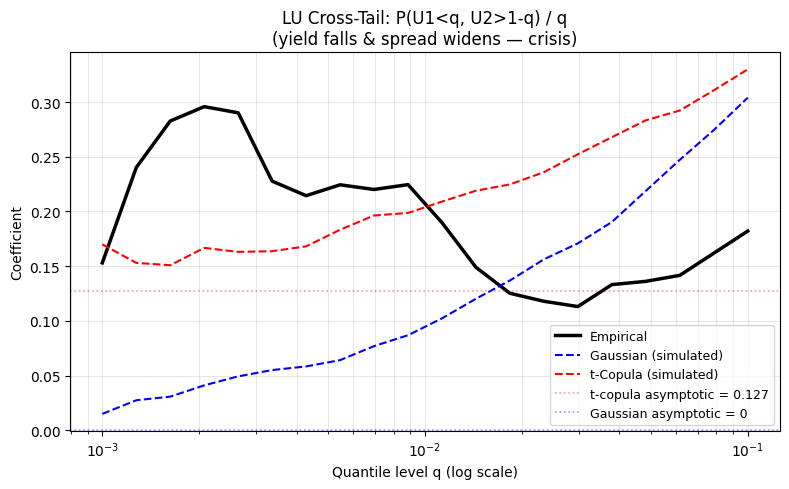

Mean rho  Gaussian: -0.4599  |  t-copula: -0.4458
t-copula asymptotic cross-tail lambda = 0.1272


In [35]:
np.random.seed(42)
N_sim = 200_000
q_levels = np.logspace(-3, -1, 20)

rho_avg_g = float(np.mean(rho_g))
rho_avg_t = float(np.mean(rho_t))

# Simulate from static Gaussian copula (average rho)
cov_g = np.array([[1.0, rho_avg_g], [rho_avg_g, 1.0]])
Z_g   = np.random.multivariate_normal([0, 0], cov_g, size=N_sim)
u1_g_sim = stats.norm.cdf(Z_g[:, 0])
u2_g_sim = stats.norm.cdf(Z_g[:, 1])

# Simulate from static t-copula (average rho, estimated nu)
L_t   = np.linalg.cholesky([[1.0, rho_avg_t], [rho_avg_t, 1.0]])
Z_raw = np.random.standard_normal((N_sim, 2)) @ L_t.T
W     = np.random.chisquare(nu_t, N_sim)
T_raw = Z_raw * np.sqrt(nu_t / W[:, np.newaxis])
u1_t_sim = stats.t.cdf(T_raw[:, 0], df=nu_t)
u2_t_sim = stats.t.cdf(T_raw[:, 1], df=nu_t)


def cross_tail_LU(a, b, q_arr):
    """P(U1 < q, U2 > 1-q) / q  — lower U1, upper U2"""
    return np.array([np.mean((a < q) & (b > 1 - q)) / q for q in q_arr])


emp_LU   = cross_tail_LU(u1c, u2c, q_levels)
sim_g_LU = cross_tail_LU(u1_g_sim, u2_g_sim, q_levels)
sim_t_LU = cross_tail_LU(u1_t_sim, u2_t_sim, q_levels)

# Asymptotic cross-tail for t-copula
lambda_cross_t = 2 * stats.t.cdf(
    -np.sqrt((nu_t + 1) * (1 + rho_avg_t) / (1 - rho_avg_t)), df=nu_t + 1
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(q_levels, emp_LU,   'k-',  lw=2.5, label='Empirical')
ax.plot(q_levels, sim_g_LU, 'b--', lw=1.5, label='Gaussian (simulated)')
ax.plot(q_levels, sim_t_LU, 'r--', lw=1.5, label='t-Copula (simulated)')
ax.axhline(lambda_cross_t, color='r', alpha=0.4, ls=':', lw=1.2,
           label=f't-copula asymptotic = {lambda_cross_t:.3f}')
ax.axhline(0.0, color='b', alpha=0.4, ls=':', lw=1.2,
           label='Gaussian asymptotic = 0')

ax.set_xscale('log')
ax.set_xlabel('Quantile level q (log scale)')
ax.set_ylabel('Coefficient')
ax.set_title('LU Cross-Tail: P(U1<q, U2>1-q) / q\n(yield falls & spread widens — crisis)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f'Mean rho  Gaussian: {rho_avg_g:.4f}  |  t-copula: {rho_avg_t:.4f}')
print(f't-copula asymptotic cross-tail lambda = {lambda_cross_t:.4f}')


Гауссова копула по построению имеет нулевую хвостовую зависимость при любом ρ — то есть она предсказывает, что совместные экстремальные события (падение доходностей и одновременное расширение спредов) практически невозможны. Эмпирические данные опровергают это: коэффициент перекрёстной хвостовой зависимости устойчиво положителен при малых q и согласуется с асимптотическим значением λ_LU ≈ 0.13, предсказываемым t-копулой с ν ≈ 6.8.

## 3. Scatter Plots

Сравнение эмпирических псевдонаблюдений с выборками из каждой копулы (статическое приближение со средним ρ). 

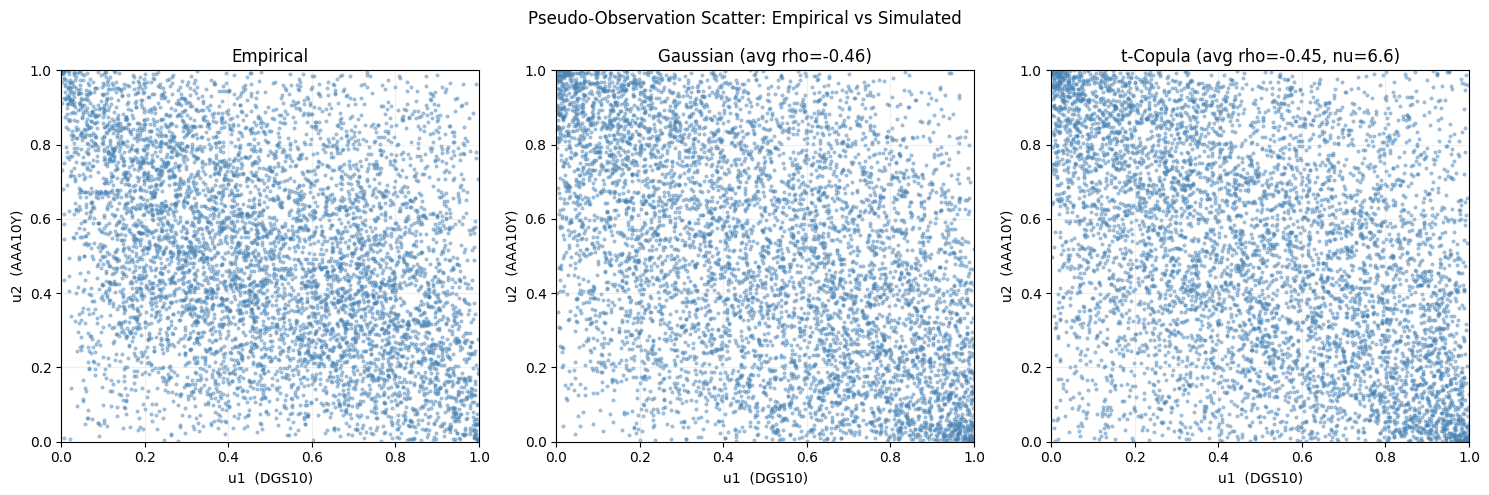

In [40]:
t_label = f't-Copula (avg rho={rho_avg_t:.2f}, nu={nu_t:.1f})'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    (u1c,          u2c,          'Empirical',                           'steelblue',     0.4),
    (u1_g_sim[:T], u2_g_sim[:T], f'Gaussian (avg rho={rho_avg_g:.2f})', 'steelblue', 0.4),
    (u1_t_sim[:T], u2_t_sim[:T], t_label,                               'steelblue',    0.4),
]

for ax, (a, b, lbl, col, alp) in zip(axes, datasets):
    ax.scatter(a, b, s=4, alpha=alp, color=col, rasterized=True)
    ax.set_xlabel('u1  (DGS10)')
    ax.set_ylabel('u2  (AAA10Y)')
    ax.set_title(lbl)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

plt.suptitle('Pseudo-Observation Scatter: Empirical vs Simulated', fontsize=12)
plt.tight_layout()
plt.show()


## 4. Сравнение динамики корреляции

Обе копулы используют достаточно похожую структуру, так как динамика корреляции $\rho$ моделируется в виде процесса ARMA(1,80)

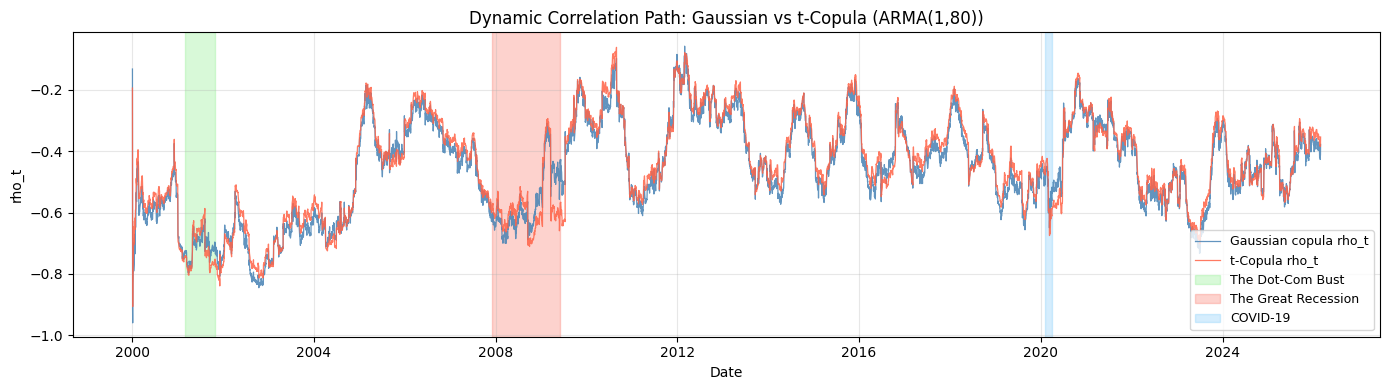

Max absolute path difference: 0.1738
Mean absolute path difference: 0.0260


In [43]:
dates = tsy_changes.index

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(dates, rho_g, color='steelblue', lw=0.9, alpha=0.85, label='Gaussian copula rho_t')
ax.plot(dates, rho_t, color='tomato',    lw=0.9, alpha=0.85, label='t-Copula rho_t')

crises = [
    ('2001-03-01', '2001-11-01', 'lightgreen',   'The Dot-Com Bust'),
    ('2007-12-01', '2009-06-01', 'salmon',        'The Great Recession'),
    ('2020-02-01', '2020-04-01', 'lightskyblue',  'COVID-19'),
]
for start, end, color, name in crises:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.35, color=color, label=name)

ax.set_xlabel('Date')
ax.set_ylabel('rho_t')
ax.set_title('Dynamic Correlation Path: Gaussian vs t-Copula (ARMA(1,80))')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

diff = rho_t - rho_g
print(f'Max absolute path difference: {np.abs(diff).max():.4f}')
print(f'Mean absolute path difference: {np.abs(diff).mean():.4f}')


## Итог

По всем рассмотренным критериям t-копула демонстрирует значительно лучшее качество описания структуры исследумых распределений по сравнению с гауссовой копулой.